<a href="https://colab.research.google.com/github/dioufabdoulaye910/tb-detection-deep-learning/blob/main/02_Preprocessing_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2 : Prétraitement des Images et Modélisation CNN

## Projet : Détection Automatique de la Tuberculose sur Radiographies Pulmonaires

Cette phase consiste à :
- Charger les images
- Prétraiter les radiographies pulmonaires
- Redimensionner les images
- Normaliser les données
- Diviser le dataset en ensembles d'entraînement et de test
- Préparer les données pour l'entraînement d'un modèle CNN

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.model_selection import train_test_split

In [3]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
data_path = "/content/drive/MyDrive/TB_Chest_Radiography_Database"

tb_path = os.path.join(data_path, "Tuberculosis")
normal_path = os.path.join(data_path, "Normal")

print("TB folder:", tb_path)
print("Normal folder:", normal_path)

TB folder: /content/drive/MyDrive/TB_Chest_Radiography_Database/Tuberculosis
Normal folder: /content/drive/MyDrive/TB_Chest_Radiography_Database/Normal


In [5]:
IMG_SIZE = 224

In [6]:
def load_images(folder, label):

    data = []

    for img_name in os.listdir(folder):

        if not img_name.lower().endswith((".png", ".jpg", ".jpeg")):
            continue

        try:

            img_path = os.path.join(folder, img_name)

            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            data.append([img, label])

        except Exception as e:
            print(f"Erreur avec {img_name}")

    return data

In [7]:
tb_data = load_images(tb_path, 1)
normal_data = load_images(normal_path, 0)

dataset = tb_data + normal_data

print("Nombre total d'images :", len(dataset))

Nombre total d'images : 4200


In [8]:
import random

random.shuffle(dataset)

In [9]:
X = np.array([item[0] for item in dataset], dtype="float32")
y = np.array([item[1] for item in dataset])

X = X / 255.0

In [10]:
X = X.astype("float32")

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [12]:
print("Train :", X_train.shape)
print("Test :", X_test.shape)

print("Train labels :", y_train.shape)
print("Test labels :", y_test.shape)

Train : (3360, 224, 224, 3)
Test : (840, 224, 224, 3)
Train labels : (3360,)
Test labels : (840,)


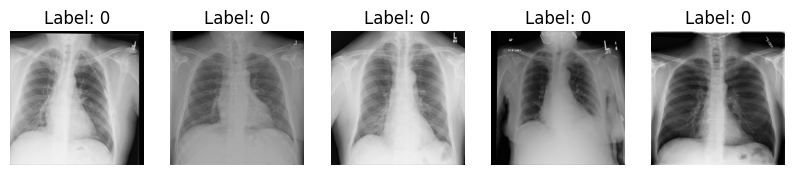

In [13]:
plt.figure(figsize=(10,5))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(X_train[i])

    plt.title(f"Label: {y_train[i]}")

    plt.axis("off")

plt.show()

In [14]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0,1]),
    y=y_train
)

class_weights = {
    0: class_weights[0],
    1: class_weights[1]
}

print(class_weights)

{0: np.float64(0.6), 1: np.float64(3.0)}


In [15]:
print(X_train.dtype)
print(X_train.shape)

float32
(3360, 224, 224, 3)


## Conclusion de la phase de prétraitement

Les radiographies pulmonaires ont été préparées avec succès pour l'entraînement d'un modèle de Deep Learning.

Les principales opérations réalisées sont :

- Chargement des images des classes Tuberculosis et Normal
- Redimensionnement des images à 224 × 224 pixels
- Normalisation des valeurs des pixels entre 0 et 1
- Création des variables d'entrée (X) et de sortie (y)
- Division du dataset en ensembles d'entraînement (80 %) et de test (20 %)
- Calcul des poids de classes afin de corriger le déséquilibre du dataset

Les données sont désormais prêtes pour l'entraînement et l'évaluation d'un modèle de classification basé sur les réseaux de neurones convolutifs (CNN).
Cette étape constitue une base essentielle pour garantir de bonnes performances lors de l’entraînement du modèle et améliorer la robustesse de la classification.